In [ ]:
import pandas as pd

data = pd.DataFrame({
    "Nilai": [
        60, 65, 70, 70, 72, 75, 75, 78,
        80, 80, 82, 85, 85, 88, 90, 92, 95
    ]
})

print(data)

    Nilai
0      60
1      65
2      70
3      70
4      72
5      75
6      75
7      78
8      80
9      80
10     82
11     85
12     85
13     88
14     90
15     92
16     95


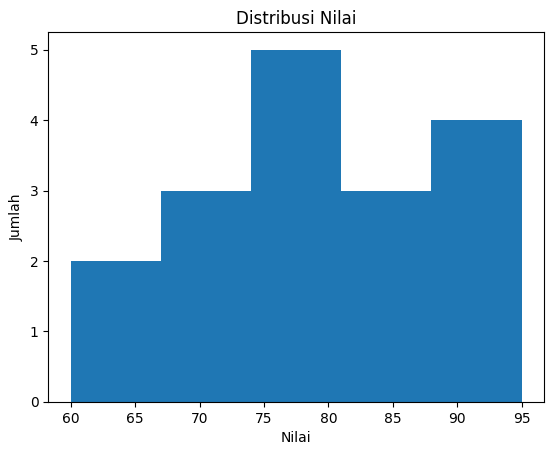

In [ ]:
import matplotlib.pyplot as plt

plt.hist(data["Nilai"], bins=5)

plt.title("Distribusi Nilai")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")

plt.show()

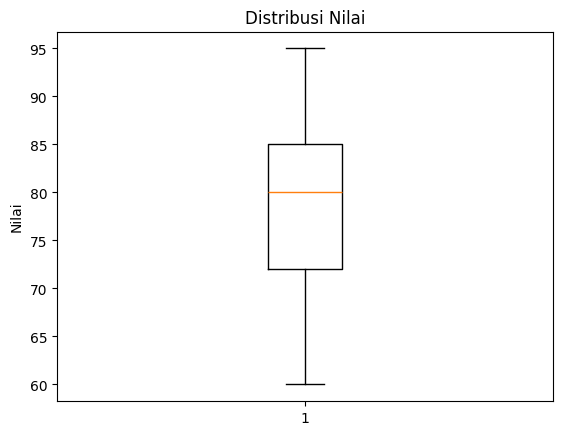

In [ ]:
plt.boxplot(data["Nilai"])

plt.title("Distribusi Nilai")
plt.ylabel("Nilai")

plt.show()

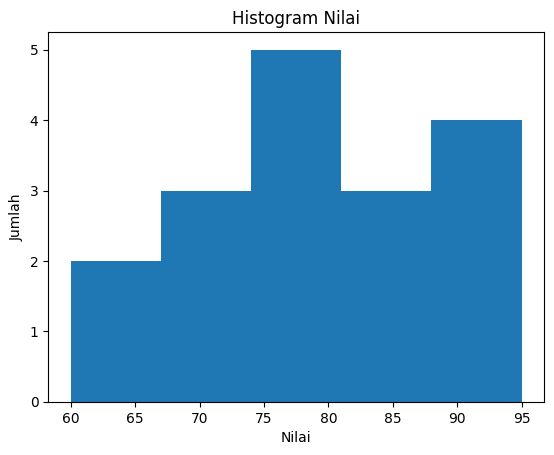

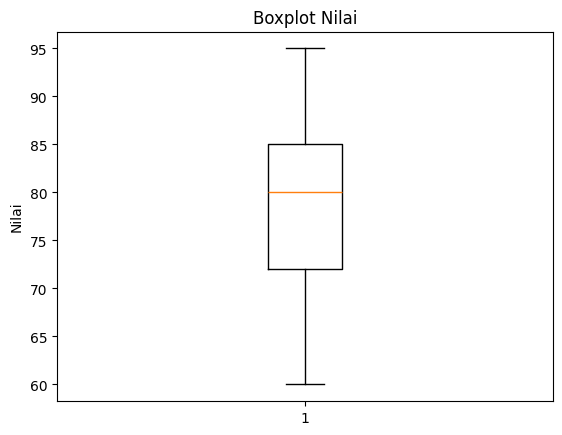

In [ ]:
plt.hist(data["Nilai"], bins=5)

plt.title("Histogram Nilai")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")

plt.show()


plt.boxplot(data["Nilai"])

plt.title("Boxplot Nilai")
plt.ylabel("Nilai")

plt.show()

In [1]:
# ============================================================
# WEEK 6 - EDA DASAR
# HARI SENIN
# Exploratory Data Analysis & Statistik Deskriptif
# Dataset: Café Dirty dari Week 5
# ============================================================

# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
from google.colab import files
from IPython.display import display
import os

print("=" * 70)
print("WEEK 6 - EXPLORATORY DATA ANALYSIS (EDA)")
print("HARI SENIN - DATA UNDERSTANDING & STATISTIK DESKRIPTIF")
print("=" * 70)


# ============================================================
# 2. UPLOAD DATASET
# ============================================================

print("\n[1] SILAKAN UPLOAD DATASET CAFÉ DIRTY / HASIL WEEK 5")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

print(f"\nDataset yang digunakan: {file_name}")


# ============================================================
# 3. LOAD DATASET OTOMATIS
# ============================================================

extension = os.path.splitext(file_name)[1].lower()

if extension == ".csv":
    # mencoba beberapa separator umum
    try:
        df = pd.read_csv(file_name)
    except:
        df = pd.read_csv(file_name, sep=";")

elif extension in [".xlsx", ".xls"]:
    df = pd.read_excel(file_name)

else:
    raise ValueError(
        "Format file tidak didukung. Gunakan CSV, XLSX, atau XLS."
    )

print("\nDataset berhasil dimuat.")
print(f"Ukuran dataset: {df.shape[0]} baris × {df.shape[1]} kolom")


# ============================================================
# 4. INFORMASI AWAL DATASET
# ============================================================

print("\n" + "=" * 70)
print("[2] 5 DATA TERATAS (HEAD)")
print("=" * 70)

display(df.head())


print("\n" + "=" * 70)
print("[3] 5 DATA TERBAWAH (TAIL)")
print("=" * 70)

display(df.tail())


# ============================================================
# 5. STRUKTUR DATA
# ============================================================

print("\n" + "=" * 70)
print("[4] STRUKTUR DATASET")
print("=" * 70)

print(f"Jumlah baris  : {df.shape[0]}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"Nama kolom    : {list(df.columns)}")


print("\nInformasi tipe data:")
df.info()


# ============================================================
# 6. TIPE DATA SETIAP KOLOM
# ============================================================

print("\n" + "=" * 70)
print("[5] TIPE DATA SETIAP KOLOM")
print("=" * 70)

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null": df.notna().sum().values,
    "Missing": df.isna().sum().values,
    "Unique": df.nunique(dropna=True).values
})

display(dtype_summary)


# ============================================================
# 7. MISSING VALUE
# ============================================================

print("\n" + "=" * 70)
print("[6] MISSING VALUE ANALYSIS")
print("=" * 70)

missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing_Value": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().mean().values * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing_Value",
    ascending=False
)

display(missing_summary)

total_missing = df.isna().sum().sum()

print(f"Total missing value dalam dataset: {total_missing}")

if total_missing == 0:
    print("Status: Tidak ditemukan missing value.")
else:
    print("Status: Dataset memiliki missing value yang perlu diperhatikan.")


# ============================================================
# 8. DUPLICATE DATA
# ============================================================

print("\n" + "=" * 70)
print("[7] DUPLICATE DATA")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print(f"Jumlah baris duplikat: {duplicate_count}")

if duplicate_count == 0:
    print("Status: Tidak ditemukan data duplikat.")
else:
    print("Status: Ditemukan data duplikat yang perlu diperhatikan.")


# ============================================================
# 9. UNIQUE DAN NUNIQUE
# ============================================================

print("\n" + "=" * 70)
print("[8] UNIQUE & NUNIQUE")
print("=" * 70)

unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique_Count": df.nunique(dropna=True).values
})

display(unique_summary)


print("\nContoh nilai unik setiap kolom:")

for column in df.columns:
    print(f"\n--- {column} ---")
    values = df[column].dropna().unique()

    # Membatasi tampilan agar output tidak terlalu panjang
    if len(values) > 20:
        print(values[:20], "...")

        print(f"Total unique value: {len(values)}")
    else:
        print(values)


# ============================================================
# 10. DESCRIPTIVE STATISTICS - NUMERIK
# ============================================================

print("\n" + "=" * 70)
print("[9] STATISTIK DESKRIPTIF VARIABEL NUMERIK")
print("=" * 70)

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print(f"Jumlah kolom numerik: {len(numeric_columns)}")

if len(numeric_columns) > 0:

    numeric_summary = df[numeric_columns].describe().T

    numeric_summary["median"] = df[numeric_columns].median()
    numeric_summary["mode"] = df[numeric_columns].mode().iloc[0]
    numeric_summary["range"] = (
        numeric_summary["max"] -
        numeric_summary["min"]
    )

    numeric_summary = numeric_summary[
        [
            "count",
            "mean",
            "median",
            "mode",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
            "range"
        ]
    ]

    numeric_summary = numeric_summary.rename(columns={
        "count": "Count",
        "mean": "Mean",
        "median": "Median",
        "mode": "Mode",
        "std": "Standard_Deviation",
        "min": "Minimum",
        "25%": "Q1",
        "50%": "Q2_Median",
        "75%": "Q3",
        "max": "Maximum",
        "range": "Range"
    })

    display(numeric_summary.round(2))

else:
    print("Tidak ditemukan kolom numerik.")


# ============================================================
# 11. STATISTIK DESKRIPTIF LENGKAP
# ============================================================

print("\n" + "=" * 70)
print("[10] DESCRIBE()")
print("=" * 70)

display(df.describe(include="all").T)


# ============================================================
# 12. VALUE COUNTS UNTUK DATA KATEGORIKAL
# ============================================================

print("\n" + "=" * 70)
print("[11] VALUE COUNTS - VARIABEL KATEGORIKAL")
print("=" * 70)

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"Jumlah kolom kategorikal: {len(categorical_columns)}")

for column in categorical_columns:

    print(f"\n--- Value Counts: {column} ---")

    value_counts = df[column].value_counts(
        dropna=False
    )

    display(
        value_counts.head(15).to_frame("Frequency")
    )


# ============================================================
# 13. STATISTIK DASAR OTOMATIS
# ============================================================

print("\n" + "=" * 70)
print("[12] RINGKASAN STATISTIK DASAR")
print("=" * 70)

if len(numeric_columns) > 0:

    basic_statistics = pd.DataFrame({
        "Variable": numeric_columns,
        "Mean": [
            df[col].mean()
            for col in numeric_columns
        ],
        "Median": [
            df[col].median()
            for col in numeric_columns
        ],
        "Mode": [
            df[col].mode().iloc[0]
            if not df[col].mode().empty
            else np.nan
            for col in numeric_columns
        ],
        "Minimum": [
            df[col].min()
            for col in numeric_columns
        ],
        "Maximum": [
            df[col].max()
            for col in numeric_columns
        ],
        "Standard_Deviation": [
            df[col].std()
            for col in numeric_columns
        ],
        "Q1": [
            df[col].quantile(0.25)
            for col in numeric_columns
        ],
        "Q2_Median": [
            df[col].quantile(0.50)
            for col in numeric_columns
        ],
        "Q3": [
            df[col].quantile(0.75)
            for col in numeric_columns
        ]
    })

    basic_statistics["Range"] = (
        basic_statistics["Maximum"] -
        basic_statistics["Minimum"]
    )

    display(basic_statistics.round(2))

else:
    basic_statistics = pd.DataFrame()


# ============================================================
# 14. INSIGHT AWAL OTOMATIS
# ============================================================

print("\n" + "=" * 70)
print("[13] INSIGHT AWAL DATASET")
print("=" * 70)

print(f"""
1. Dataset memiliki {df.shape[0]:,} baris dan {df.shape[1]} kolom.

2. Variabel numerik yang ditemukan:
   {numeric_columns if numeric_columns else 'Tidak ada'}

3. Variabel kategorikal yang ditemukan:
   {categorical_columns if categorical_columns else 'Tidak ada'}

4. Total missing value:
   {total_missing}

5. Total data duplikat:
   {duplicate_count}
""")

if len(numeric_columns) > 0:

    print("Statistik utama variabel numerik:")

    for col in numeric_columns:

        mean_value = df[col].mean()
        median_value = df[col].median()
        min_value = df[col].min()
        max_value = df[col].max()

        print(
            f"- {col}: "
            f"Mean={mean_value:.2f}, "
            f"Median={median_value:.2f}, "
            f"Min={min_value:.2f}, "
            f"Max={max_value:.2f}"
        )


# ============================================================
# 15. EXPORT STATISTICAL SUMMARY.xlsx
# ============================================================

print("\n" + "=" * 70)
print("[14] MEMBUAT STATISTICAL SUMMARY.xlsx")
print("=" * 70)

output_file = "Statistical Summary.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # Sheet 1 - Dataset Info
    dataset_info = pd.DataFrame({
        "Information": [
            "Dataset",
            "Rows",
            "Columns",
            "Numeric Columns",
            "Categorical Columns",
            "Total Missing Values",
            "Duplicate Rows"
        ],
        "Value": [
            file_name,
            df.shape[0],
            df.shape[1],
            len(numeric_columns),
            len(categorical_columns),
            total_missing,
            duplicate_count
        ]
    })

    dataset_info.to_excel(
        writer,
        sheet_name="Dataset Info",
        index=False
    )

    # Sheet 2 - Data Types
    dtype_summary.to_excel(
        writer,
        sheet_name="Data Types",
        index=False
    )

    # Sheet 3 - Missing Values
    missing_summary.to_excel(
        writer,
        sheet_name="Missing Values",
        index=False
    )

    # Sheet 4 - Unique Values
    unique_summary.to_excel(
        writer,
        sheet_name="Unique Values",
        index=False
    )

    # Sheet 5 - Statistical Summary
    if not basic_statistics.empty:
        basic_statistics.round(2).to_excel(
            writer,
            sheet_name="Statistical Summary",
            index=False
        )

    # Sheet 6 - Describe
    df.describe(
        include="all"
    ).T.to_excel(
        writer,
        sheet_name="Describe"
    )

    # Sheet 7 - Categorical Summary
    if categorical_columns:

        categorical_summary = pd.DataFrame({
            "Column": categorical_columns,
            "Unique_Count": [
                df[col].nunique()
                for col in categorical_columns
            ],
            "Most_Frequent": [
                df[col].mode().iloc[0]
                if not df[col].mode().empty
                else np.nan
                for col in categorical_columns
            ],
            "Frequency": [
                df[col].value_counts().iloc[0]
                if not df[col].value_counts().empty
                else 0
                for col in categorical_columns
            ]
        })

        categorical_summary.to_excel(
            writer,
            sheet_name="Categorical Summary",
            index=False
        )


# ============================================================
# 16. DOWNLOAD FILE
# ============================================================

print(f"\nFile berhasil dibuat: {output_file}")

files.download(output_file)


# ============================================================
# 17. KESIMPULAN HARI SENIN
# ============================================================

print("\n" + "=" * 70)
print("KESIMPULAN - WEEK 6 HARI SENIN")
print("=" * 70)

print("""
Hari Senin telah menyelesaikan tahap awal Exploratory Data Analysis (EDA):

✓ Dataset berhasil dimuat dan diperiksa
✓ Struktur dataset telah dianalisis
✓ Tipe data setiap variabel telah diperiksa
✓ Missing value telah dianalisis
✓ Duplicate data telah diperiksa
✓ Unique dan nunique telah dianalisis
✓ describe() telah digunakan
✓ Variabel numerik dan kategorikal telah diidentifikasi
✓ Mean telah dihitung
✓ Median telah dihitung
✓ Mode telah dihitung
✓ Minimum telah dihitung
✓ Maksimum telah dihitung
✓ Standar deviasi telah dihitung
✓ Kuartil Q1, Q2, dan Q3 telah dihitung
✓ Range telah dihitung
✓ Insight awal telah dibuat
✓ Statistical Summary.xlsx telah dibuat

OUTPUT HARI SENIN:
1. Notebook.ipynb
2. Statistical Summary.xlsx
""")

print("=" * 70)
print("SELESAI - LANJUT KE HARI SELASA: ANALISIS UNIVARIATE")
print("=" * 70)

WEEK 6 - EXPLORATORY DATA ANALYSIS (EDA)
HARI SENIN - DATA UNDERSTANDING & STATISTIK DESKRIPTIF

[1] SILAKAN UPLOAD DATASET CAFÉ DIRTY / HASIL WEEK 5


Saving Final Clean Dataset.csv to Final Clean Dataset.csv

Dataset yang digunakan: Final Clean Dataset.csv

Dataset berhasil dimuat.
Ukuran dataset: 10000 baris × 10 kolom

[2] 5 DATA TERATAS (HEAD)


,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date,Year,Month
0,TXN_1961373,COFFEE,2.0,2.0,4.0,CREDIT CARD,TAKEAWAY,2023-09-08,2023.0,September
1,TXN_4977031,CAKE,4.0,3.0,12.0,CASH,IN-STORE,2023-05-16,2023.0,May
2,TXN_4271903,COOKIE,4.0,1.0,8.0,CREDIT CARD,IN-STORE,2023-07-19,2023.0,July
3,TXN_7034554,SALAD,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,2023.0,April
4,TXN_3160411,COFFEE,2.0,2.0,4.0,DIGITAL WALLET,IN-STORE,2023-06-11,2023.0,June



[3] 5 DATA TERBAWAH (TAIL)


,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date,Year,Month
9995,TXN_7672686,COFFEE,2.0,2.0,4.0,DIGITAL WALLET,UNKNOWN,2023-08-30,2023.0,August
9996,TXN_9659401,JUICE,3.0,3.0,3.0,DIGITAL WALLET,TAKEAWAY,2023-06-02,2023.0,June
9997,TXN_5255387,COFFEE,4.0,2.0,8.0,DIGITAL WALLET,TAKEAWAY,2023-03-02,2023.0,March
9998,TXN_7695629,COOKIE,3.0,3.0,3.0,DIGITAL WALLET,TAKEAWAY,2023-12-02,2023.0,December
9999,TXN_6170729,SANDWICH,3.0,4.0,12.0,CASH,IN-STORE,2023-11-07,2023.0,November


...

,Variable,Mean,Median,Mode,Minimum,Maximum,Standard_Deviation,Q1,Q2_Median,Q3,Range
0,Quantity,3.03,3.0,3.0,1.0,5.0,1.38,2.0,3.0,4.0,4.0
1,Price_Per_Unit,2.95,3.0,3.0,1.0,5.0,1.24,2.0,3.0,4.0,4.0
2,Total_Spent,8.88,8.0,8.0,1.0,25.0,5.86,4.0,8.0,12.0,24.0
3,Year,2023.00,2023.0,2023.0,2023.0,2023.0,0.00,2023.0,2023.0,2023.0,0.0



[13] INSIGHT AWAL DATASET

1. Dataset memiliki 10,000 baris dan 10 kolom.

2. Variabel numerik yang ditemukan:
   ['Quantity', 'Price_Per_Unit', 'Total_Spent', 'Year']

3. Variabel kategorikal yang ditemukan:
   ['Transaction_ID', 'Item', 'Payment_Method', 'Location', 'Transaction_Date', 'Month']

4. Total missing value:
   1380

5. Total data duplikat:
   0

Statistik utama variabel numerik:
- Quantity: Mean=3.03, Median=3.00, Min=1.00, Max=5.00
- Price_Per_Unit: Mean=2.95, Median=3.00, Min=1.00, Max=5.00
- Total_Spent: Mean=8.88, Median=8.00, Min=1.00, Max=25.00
- Year: Mean=2023.00, Median=2023.00, Min=2023.00, Max=2023.00

[14] MEMBUAT STATISTICAL SUMMARY.xlsx

File berhasil dibuat: Statistical Summary.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


KESIMPULAN - WEEK 6 HARI SENIN

Hari Senin telah menyelesaikan tahap awal Exploratory Data Analysis (EDA):

✓ Dataset berhasil dimuat dan diperiksa
✓ Struktur dataset telah dianalisis
✓ Tipe data setiap variabel telah diperiksa
✓ Missing value telah dianalisis
✓ Duplicate data telah diperiksa
✓ Unique dan nunique telah dianalisis
✓ describe() telah digunakan
✓ Variabel numerik dan kategorikal telah diidentifikasi
✓ Mean telah dihitung
✓ Median telah dihitung
✓ Mode telah dihitung
✓ Minimum telah dihitung
✓ Maksimum telah dihitung
✓ Standar deviasi telah dihitung
✓ Kuartil Q1, Q2, dan Q3 telah dihitung
✓ Range telah dihitung
✓ Insight awal telah dibuat
✓ Statistical Summary.xlsx telah dibuat

OUTPUT HARI SENIN:
1. Notebook.ipynb
2. Statistical Summary.xlsx

SELESAI - LANJUT KE HARI SELASA: ANALISIS UNIVARIATE
